# Trabajo Práctico — Fundamentos de la IA
## Clasificación de dirección de precios con Regresión Logística vs. Perceptrón Multicapa (MLP)

**Maestría en Inteligencia Artificial — Universidad de Palermo**

---

### Resumen

Este trabajo demuestra fundamentos de aprendizaje automático aplicados a un problema
financiero: **predecir la dirección futura del precio de una acción** (sube / lateral / baja)
a partir de una ventana de datos históricos y de indicadores de análisis técnico.

El eje del trabajo es una **comparativa metodológica** entre dos modelos de complejidad
creciente, siguiendo el arco conceptual de los primeros capítulos de *Deep Learning*
(Goodfellow, Bengio & Courville, 2016):

1. **Regresión Logística** — modelo lineal de referencia (Cap. 5, *Machine Learning Basics*).
2. **Perceptrón Multicapa (MLP)** — red neuronal feedforward con no-linealidad (Cap. 6, *Deep Feedforward Networks*).

Sobre estos modelos se ilustran además: **regularización** (Cap. 7), **optimización del
entrenamiento** (Cap. 8) y los **fundamentos probabilísticos** de la función de pérdida (Cap. 3).

> **Aclaración metodológica importante:** este trabajo NO pretende construir un sistema
> rentable de trading. La predicción de dirección de precios es un problema notoriamente
> difícil y cercano al azar en mercados eficientes. El objetivo es **pedagógico**: mostrar
> cómo se plantea, entrena, regulariza y evalúa correctamente un clasificador, y cómo se
> comparan modelos de forma honesta evitando *data leakage*.


## Configuración técnica del entorno

Instalamos las dependencias. En Google Colab, `yfinance` y `ta` no vienen preinstalados.


In [1]:
!pip install yfinance ta --quiet

  Preparing metadata (setup.py) ... done


In [2]:
import os
# Deben fijarse ANTES de importar tensorflow para que surtan efecto por completo.
os.environ["PYTHONHASHSEED"] = "42"
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import ta

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix,
                             roc_curve, auc,
                             precision_recall_curve, average_precision_score)
from sklearn.preprocessing import label_binarize

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
# np.random.seed/tf.random.set_seed no alcanzan para reproducibilidad bit-a-bit:
# esto fuerza a que toda operacion de TF use una implementacion determinista.
tf.config.experimental.enable_op_determinism()

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## 1. Introducción y problema

### 1.1 El problema de aprendizaje (Goodfellow, Cap. 5)

Goodfellow define una tarea de aprendizaje automático mediante tres componentes: la **tarea T**,
la **medida de desempeño P** y la **experiencia E**.

| Componente | En este trabajo |
|---|---|
| **Tarea T** | Clasificar la dirección del precio a *k* días vista en 3 clases: `SUBE`, `LATERAL`, `BAJA`. |
| **Desempeño P** | *Accuracy* y *F1-score* macro sobre un conjunto de prueba fuera de muestra. |
| **Experiencia E** | Ventanas históricas de precios (OHLCV) + indicadores técnicos de una acción del mercado. |

### 1.2 ¿Por qué comparar un modelo lineal contra uno no lineal?

El **teorema de aproximación universal** (Goodfellow, Cap. 6.4.1) establece que una red
feedforward con al menos una capa oculta y suficientes neuronas puede aproximar cualquier
función continua. La regresión logística, en cambio, sólo puede trazar **fronteras de decisión
lineales**. La comparativa permite responder empíricamente: *¿el problema de dirección de
precios tiene estructura no lineal que un MLP pueda capturar y un modelo lineal no?*

### 1.3 Fundamento probabilístico de la pérdida (Cap. 3)

Ambos modelos terminan en una capa **softmax** que produce una distribución de probabilidad
sobre las 3 clases. El entrenamiento minimiza la **entropía cruzada** (*cross-entropy*), que
equivale a la **estimación de máxima verosimilitud** de los parámetros dado el conjunto de datos.


## 2. Datos y análisis exploratorio

El activo utilizado es RELIANCE, fijado como canónico antes de observar cualquier resultado
sobre datos reales: elegirlo después de correr el experimento introduciría sesgo de selección,
exactamente el tipo de deshonestidad metodológica que este trabajo busca evitar. La fuente
primaria es el dataset Kaggle *Stock Market Data — Nifty 100 (5 min)*; si el archivo
correspondiente no está disponible, el pipeline recurre a `yfinance` como alternativa
reproducible. Se descarga el histórico OHLCV (*Open, High, Low, Close, Volume*) del activo
elegido.


In [3]:
# --- Fuente de datos ---
# Fuente primaria: dataset Kaggle "Stock Market Data - Nifty 100 (5-min)".
# Indicar la ruta a UNO de los CSV del dataset (subido a Colab o en Drive).
# Si se deja vacío, el notebook usa yfinance como fallback reproducible.
CSV_NIFTY   = "/content/RELIANCE_5minute.csv"          # ej: "/content/RELIANCE_5minute.csv"
TICKER      = "GGAL"      # fallback si no hay CSV: activo de ejemplo para yfinance
FECHA_INI   = "2010-01-01"
FECHA_FIN   = "2024-12-31"


In [4]:
from pathlib import Path

if CSV_NIFTY and Path(CSV_NIFTY).exists():
    # ---- Fuente primaria: dataset Kaggle Nifty 100 (velas de 5 minutos) ----
    raw = pd.read_csv(CSV_NIFTY)
    raw.columns = [c.lower().strip() for c in raw.columns]
    raw["date"] = pd.to_datetime(raw["date"])
    raw = raw.set_index("date").sort_index()

    # Resampleo 5-min -> DIARIO. Motivo metodológico: mantiene el significado de
    # los hiperparámetros (VENTANA=30 días, HORIZONTE=5 días, indicadores con
    # ventanas diarias estándar: RSI-14, SMA-20) y reduce el ruido microestructural
    # del intradía, que a 5 minutos domina por completo la señal.
    df = pd.DataFrame({
        "Open":   raw["open"].resample("1D").first(),
        "High":   raw["high"].resample("1D").max(),
        "Low":    raw["low"].resample("1D").min(),
        "Close":  raw["close"].resample("1D").last(),
        "Volume": raw["volume"].resample("1D").sum(),
    }).dropna()
    df.index.name = "Date"
    TICKER = Path(CSV_NIFTY).stem.split("_")[0]  # nombre del activo para los gráficos
    FUENTE = f"Kaggle Nifty 100 — {TICKER} (5-min resampleado a diario)"
else:
    # ---- Fallback reproducible: yfinance ----
    df = yf.download(TICKER, start=FECHA_INI, end=FECHA_FIN, auto_adjust=True)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df.dropna()
    FUENTE = f"yfinance — {TICKER} (diario)"

print(f"Fuente de datos: {FUENTE}")
print(f"Filas: {len(df)}")
print(f"Rango: {df.index.min().date()} a {df.index.max().date()}")
df.head()


Fuente de datos: Kaggle Nifty 100 — RELIANCE (5-min resampleado a diario)
Filas: 2770
Rango: 2015-02-02 a 2026-04-09


,Open,High,Low,Close,Volume
Date,,,,,
2015-02-02,216.45,217.15,213.80,214.40,18650614
2015-02-03,215.75,222.10,215.70,221.00,16537992
2015-02-04,221.90,222.80,218.60,218.75,13598266
2015-02-05,219.80,221.90,216.65,217.55,11935056
2015-02-06,218.20,219.50,213.20,215.10,8735110


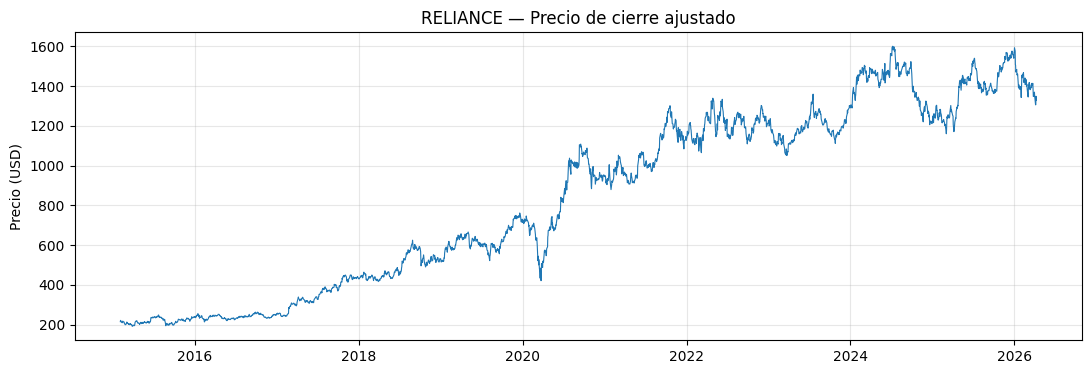

In [5]:
# Visualización del precio de cierre
plt.figure(figsize=(13, 4))
plt.plot(df.index, df["Close"], linewidth=0.8)
plt.title(f"{TICKER} — Precio de cierre ajustado")
plt.ylabel("Precio (USD)")
plt.grid(alpha=0.3)
plt.show()

La serie no exhibe una media estable en el tiempo: atraviesa tramos de tendencia sostenida
— alzas y caídas prolongadas — sin revertir hacia un nivel de referencia fijo. Esta falta de
estacionariedad en el nivel de precio es la primera razón para no alimentar al modelo con el
precio crudo, y motiva trabajar en su lugar con retornos e indicadores derivados (sección de
ingeniería de características).


### Análisis exploratorio

Antes de construir features o etiquetas conviene caracterizar empíricamente la serie: ¿son los
retornos aproximadamente gaussianos?, ¿hay estructura temporal aprovechable en la dirección del
precio o en su volatilidad? Las evidencias siguientes responden estas preguntas y anclan las
decisiones metodológicas de las secciones posteriores.


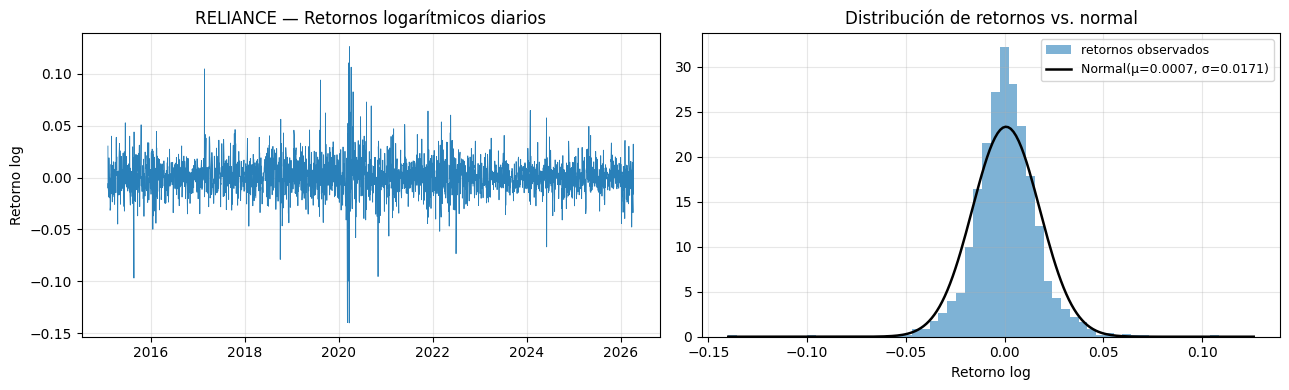

In [6]:
log_ret_eda = np.log(df["Close"] / df["Close"].shift(1)).dropna()

mu, sigma = log_ret_eda.mean(), log_ret_eda.std()
x = np.linspace(log_ret_eda.min(), log_ret_eda.max(), 200)
densidad_normal = np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].plot(df.index[1:], log_ret_eda, linewidth=0.6, color="#2980b9")
ax[0].set_title(f"{TICKER} — Retornos logarítmicos diarios")
ax[0].set_ylabel("Retorno log"); ax[0].grid(alpha=0.3)

ax[1].hist(log_ret_eda, bins=60, density=True, color="#2980b9", alpha=0.6, label="retornos observados")
ax[1].plot(x, densidad_normal, color="black", lw=1.8, label=f"Normal(μ={mu:.4f}, σ={sigma:.4f})")
ax[1].set_title("Distribución de retornos vs. normal")
ax[1].set_xlabel("Retorno log"); ax[1].legend(fontsize=9); ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

El histograma muestra colas más pesadas que la densidad normal ajustada con la misma media y
desvío: hay más retornos extremos — positivos y negativos — de los que una distribución
gaussiana predeciría. Esta propiedad, bien documentada en series financieras, implica que los
eventos de baja o alza abrupta son más frecuentes de lo que asumiría un modelo que tratara los
retornos como normales, y refuerza la necesidad de indicadores de volatilidad (como `vol10`)
además de los de dirección.


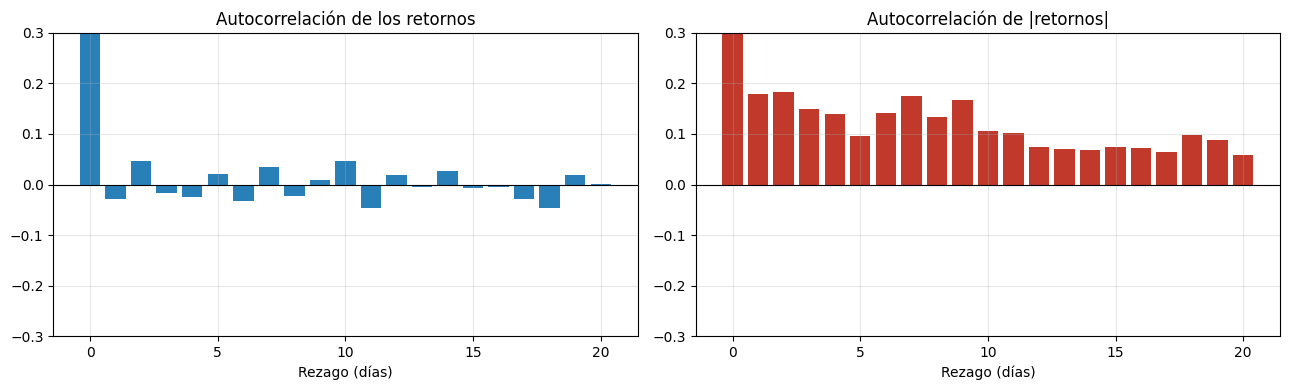

In [7]:
def autocorrelacion(serie, nlags):
    x = serie.values - serie.values.mean()
    var = np.sum(x ** 2)
    return np.array([1.0] + [np.sum(x[:-lag] * x[lag:]) / var for lag in range(1, nlags + 1)])

NLAGS = 20
acf_ret = autocorrelacion(log_ret_eda, NLAGS)
acf_abs = autocorrelacion(log_ret_eda.abs(), NLAGS)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(range(NLAGS + 1), acf_ret, color="#2980b9")
ax[0].axhline(0, color="black", lw=0.8)
ax[0].set_title("Autocorrelación de los retornos")
ax[0].set_xlabel("Rezago (días)"); ax[0].set_ylim(-0.3, 0.3); ax[0].grid(alpha=0.3)

ax[1].bar(range(NLAGS + 1), acf_abs, color="#c0392b")
ax[1].axhline(0, color="black", lw=0.8)
ax[1].set_title("Autocorrelación de |retornos|")
ax[1].set_xlabel("Rezago (días)"); ax[1].set_ylim(-0.3, 0.3); ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

La autocorrelación de los retornos es prácticamente nula en todos los rezagos, lo que es
consistente con que la dirección del retorno de un día no predice la del día siguiente — el
argumento estadístico detrás de la dificultad del problema de clasificación de este trabajo. La
autocorrelación de los retornos absolutos, en cambio, es sistemáticamente positiva: los días de
alta volatilidad tienden a agruparse con otros días de alta volatilidad (*volatility
clustering*). Es decir, la magnitud del movimiento sí tiene estructura temporal aunque su signo
no la tenga, lo que explica por qué los indicadores de volatilidad aportan información aun
cuando la dirección pura sea casi impredecible.


**Conclusión.** Las evidencias anteriores — precio no estacionario, retornos con colas
pesadas y volatilidad autocorrelacionada — comparten una misma implicación: los datos violan el
supuesto de observaciones independientes e idénticamente distribuidas (i.i.d.) que subyace a un
split aleatorio train/test. Si el orden temporal contiene información (la volatilidad de hoy
predice la de mañana), mezclar aleatoriamente días de entrenamiento y de prueba filtraría esa
estructura hacia el conjunto de prueba, produciendo una evaluación optimista y poco honesta. Por
eso el split de este trabajo es estrictamente temporal, con purga en la frontera — la decisión
metodológica que se desarrolla en la sección de metodología anti-*leakage*.


## 3. Diseño experimental

El experimento queda definido por tres hiperparámetros, con notación fija en todo el
documento: el umbral θ (theta), el horizonte k y la ventana w.

- **θ (umbral)** — banda de retorno, en valor absoluto, que separa un movimiento direccional
  del ruido de corto plazo. Un retorno futuro con $|r| \le \theta$ se etiqueta **LATERAL**;
  por fuera de esa banda, **SUBE** o **BAJA** según el signo. Se fija en θ = 2%: suficientemente
  amplio para no confundir microfluctuaciones con dirección, y suficientemente angosto para no
  vaciar de muestras las clases SUBE/BAJA.
- **k (horizonte)** — cantidad de días hacia adelante sobre la que se mide el retorno futuro
  que define la etiqueta. Se fija en k = 5 (una semana bursátil), un horizonte corto,
  consistente con la evidencia de que la dirección de precios pierde predictibilidad
  rápidamente a medida que k crece.
- **w (ventana)** — cantidad de días de historia de los indicadores técnicos que ve el modelo
  en cada predicción. Se fija en w = 30, aproximadamente un mes y medio bursátil: suficiente
  para que indicadores como el RSI-14 o el MACD ya estén en régimen estable dentro de la
  ventana.

El split entrenamiento/prueba es temporal (80%/20%, sin aleatorización), con una purga de
tamaño k en la frontera para eliminar el solapamiento entre las etiquetas de entrenamiento y
el período de prueba — se retoma en la sección de metodología anti-*leakage*.


In [8]:
# --- Definición de la etiqueta ---
VENTANA     = 30          # w: días de historia que ve el modelo (features)
HORIZONTE   = 5           # k: días hacia adelante para la etiqueta de dirección
UMBRAL      = 0.02        # theta: +/- 2%, zona muerta para la clase LATERAL

# --- Split y entrenamiento ---
TEST_FRAC   = 0.20        # último 20% temporal para test (NO aleatorio)
EPOCHS      = 100
BATCH_SIZE  = 64

CLASES = {0: "BAJA", 1: "LATERAL", 2: "SUBE"}

## 4. Ingeniería de características: indicadores de análisis técnico

En lugar de darle al modelo el precio crudo (que es no estacionario y con tendencia), se
construyen **indicadores de análisis técnico** — las mismas herramientas que usa un analista
humano. Esto es *feature engineering* clásico (Goodfellow, Cap. 5.4): representar el dato de
forma que la estructura relevante sea más accesible para el modelo.

Indicadores elegidos:

- **Retornos logarítmicos** — captura el cambio relativo, es aproximadamente estacionario.
- **RSI (Relative Strength Index)** — momento; detecta sobrecompra/sobreventa.
- **MACD** — cruce de medias móviles exponenciales; detecta cambios de tendencia.
- **Bandas de Bollinger (%B)** — posición del precio respecto a su volatilidad reciente.
- **Media móvil relativa** — precio respecto a su media de 20 días.
- **Volatilidad** — desvío estándar móvil de los retornos.


In [9]:
d = df.copy()

# Retorno logarítmico diario
d["log_ret"] = np.log(d["Close"] / d["Close"].shift(1))

# RSI (14)
d["rsi"] = ta.momentum.RSIIndicator(d["Close"], window=14).rsi()

# MACD (histograma)
macd = ta.trend.MACD(d["Close"])
d["macd_diff"] = macd.macd_diff()

# Bandas de Bollinger — %B
bb = ta.volatility.BollingerBands(d["Close"], window=20, window_dev=2)
d["bb_pctb"] = bb.bollinger_pband()

# Precio relativo a media móvil de 20
d["sma20_rel"] = d["Close"] / d["Close"].rolling(20).mean() - 1

# Volatilidad (desvío móvil de retornos, 10 días)
d["vol10"] = d["log_ret"].rolling(10).std()

FEATURES = ["log_ret", "rsi", "macd_diff", "bb_pctb", "sma20_rel", "vol10"]

d = d.dropna().reset_index(drop=False)
print(f"Filas tras calcular indicadores: {len(d)}")
d[FEATURES].describe().round(3)

Filas tras calcular indicadores: 2737


,log_ret,rsi,macd_diff,bb_pctb,sma20_rel,vol10
count,2737.000,2737.000,2737.000,2737.000,2737.000,2737.000
mean,0.001,52.878,-0.021,0.546,0.007,0.015
std,0.017,12.000,4.819,0.332,0.042,0.008
min,-0.140,17.017,-22.122,-0.409,-0.263,0.004
25%,-0.008,44.079,-2.319,0.284,-0.018,0.011
50%,0.001,52.452,0.057,0.562,0.005,0.014
75%,0.009,61.767,2.441,0.815,0.031,0.017
max,0.126,84.601,18.333,1.484,0.213,0.092


## 5. Etiquetado

Este es el paso metodológico más delicado. Para cada día *t* se mira el retorno a horizonte k
días vista, $r_t = \dfrac{\text{Close}_{t+k}}{\text{Close}_t} - 1$, y se etiqueta con el umbral
θ definido en el diseño experimental:

- $r_t > +\theta \Rightarrow$ **SUBE** (clase 2)
- $r_t < -\theta \Rightarrow$ **BAJA** (clase 0)
- en otro caso $\Rightarrow$ **LATERAL** (clase 1)

La etiqueta usa precios **futuros** — eso es correcto porque es lo que se busca predecir. El
*leakage* se evita más adelante, en el split temporal: no se permite que días del período de
prueba aparezcan en el entrenamiento.


In [10]:
# Retorno futuro a HORIZONTE dias
d["fut_ret"] = d["Close"].shift(-HORIZONTE) / d["Close"] - 1

def etiquetar(r):
    if r > UMBRAL:   return 2   # SUBE
    if r < -UMBRAL:  return 0   # BAJA
    return 1                    # LATERAL

d["label"] = d["fut_ret"].apply(etiquetar)

# Las ultimas HORIZONTE filas no tienen futuro -> se descartan
d = d.dropna(subset=["fut_ret"]).reset_index(drop=True)

# Distribucion de clases
dist = d["label"].value_counts().sort_index()
print("Distribución de clases:")
for k, v in dist.items():
    print(f"  {CLASES[k]:8s}: {v:5d}  ({v/len(d)*100:.1f}%)")

Distribución de clases:
  BAJA    :   622  (22.8%)
  LATERAL :  1298  (47.5%)
  SUBE    :   812  (29.7%)


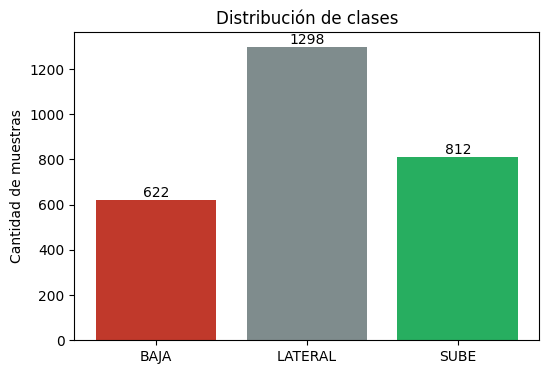

In [11]:
# Visualizamos el balance de clases
plt.figure(figsize=(6, 4))
plt.bar([CLASES[i] for i in dist.index], dist.values,
        color=["#c0392b", "#7f8c8d", "#27ae60"])
plt.title("Distribución de clases")
plt.ylabel("Cantidad de muestras")
for i, v in enumerate(dist.values):
    plt.text(i, v, str(v), ha="center", va="bottom")
plt.show()

La distribución resultante depende directamente del umbral θ: valores más chicos angostan la
zona LATERAL y trasladan masa hacia SUBE/BAJA, mientras que valores más grandes hacen lo
opuesto. Un desbalance marcado entre clases — por ejemplo, si LATERAL domina ampliamente — es
la razón metodológica para usar F1 macro en lugar de accuracy como métrica principal, y para
ponderar las clases en el entrenamiento del MLP (sección de modelos).


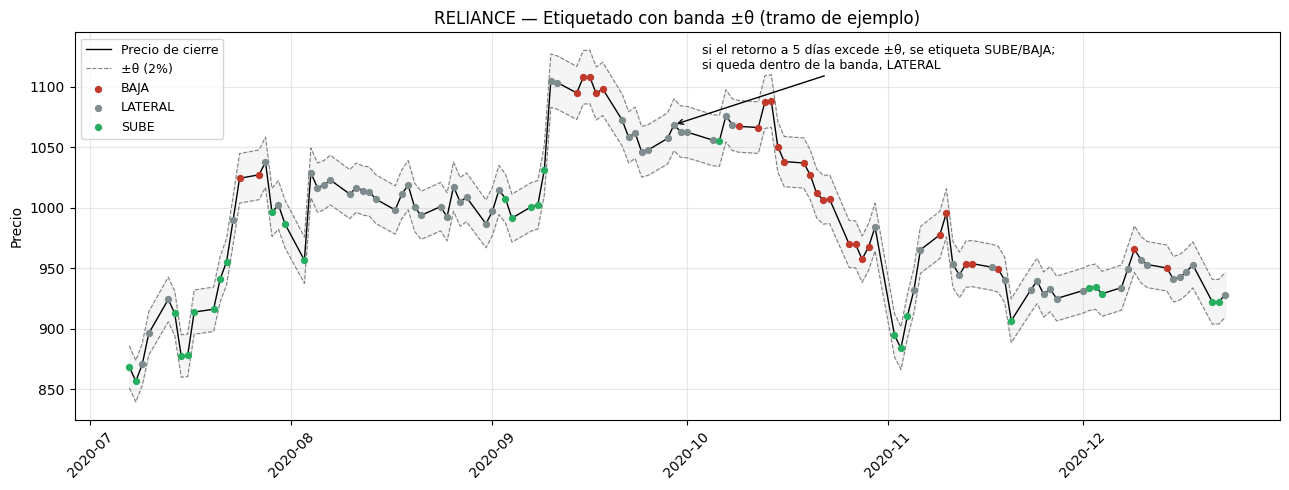

In [12]:
# Etiquetado sobre un tramo de la serie: bandas +/-theta y clase resultante
tam_ventana = min(120, len(d) // 2)
ini = max(0, len(d) // 2 - tam_ventana // 2)
tramo = d.iloc[ini: ini + tam_ventana].copy()

banda_sup = tramo["Close"] * (1 + UMBRAL)
banda_inf = tramo["Close"] * (1 - UMBRAL)
colores_clase = {0: "#c0392b", 1: "#7f8c8d", 2: "#27ae60"}

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(tramo["Date"], tramo["Close"], color="black", linewidth=1, label="Precio de cierre", zorder=3)
ax.plot(tramo["Date"], banda_sup, color="gray", ls="--", linewidth=0.8, label=f"±θ ({UMBRAL:.0%})")
ax.plot(tramo["Date"], banda_inf, color="gray", ls="--", linewidth=0.8)
ax.fill_between(tramo["Date"], banda_inf, banda_sup, color="gray", alpha=0.08)

for clase, color in colores_clase.items():
    sub = tramo[tramo["label"] == clase]
    ax.scatter(sub["Date"], sub["Close"], color=color, s=18, zorder=4, label=CLASES[clase])

idx_ej = tramo.index[len(tramo) // 2]
ax.annotate(
    f"si el retorno a {HORIZONTE} días excede ±θ, se etiqueta SUBE/BAJA;\nsi queda dentro de la banda, LATERAL",
    xy=(tramo.loc[idx_ej, "Date"], tramo.loc[idx_ej, "Close"]),
    xytext=(20, 40), textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="black"), fontsize=9,
)
ax.set_title(f"{TICKER} — Etiquetado con banda ±θ (tramo de ejemplo)")
ax.set_ylabel("Precio"); ax.legend(loc="upper left", fontsize=9); ax.grid(alpha=0.3)
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

Cada punto sobre la serie está coloreado según la clase que resultó de comparar el precio k
días más adelante contra la banda ±θ anclada en ese día: verde cuando el retorno superó +θ
(SUBE), rojo cuando quedó por debajo de −θ (BAJA), y gris cuando permaneció dentro de la banda
(LATERAL). El gráfico hace visible que la frontera entre clases no es un evento raro ni trivial
de anticipar a simple vista: tramos con pendiente similar terminan etiquetados de forma
distinta según cuánto se movió el precio en la ventana de k días siguiente.


### Sensibilidad de la distribución de clases a θ

¿Por qué θ = 2% y no otro valor? Como la etiqueta surge de comparar `fut_ret` — ya calculado —
contra el umbral, recalcular la distribución de clases para otros valores de θ es un
re-etiquetado trivial: no requiere volver a calcular indicadores ni entrenar ningún modelo, y
por eso debe resolverse en milisegundos.


In [13]:
import time

THETAS_SENSIBILIDAD = [0.005, 0.01, 0.02, 0.03, 0.05]

t0 = time.time()
distribuciones_theta = {}
for theta in THETAS_SENSIBILIDAD:
    etiquetas_theta = d["fut_ret"].apply(lambda r, th=theta: 2 if r > th else (0 if r < -th else 1))
    distribuciones_theta[theta] = etiquetas_theta.value_counts(normalize=True).reindex([0, 1, 2], fill_value=0.0)
tiempo_sensibilidad = time.time() - t0

# Si esto tarda mas de 10s, algo esta recalculando indicadores o reentrenando por error
assert tiempo_sensibilidad < 10, (
    f"la sensibilidad a theta tardo {tiempo_sensibilidad:.1f}s (>10s): solo debe re-etiquetar, "
    "no recalcular features ni reentrenar modelos"
)
print(f"Tiempo de cómputo: {tiempo_sensibilidad * 1000:.1f} ms (solo re-etiquetado, sin reentrenar)")

Tiempo de cómputo: 26.9 ms (solo re-etiquetado, sin reentrenar)


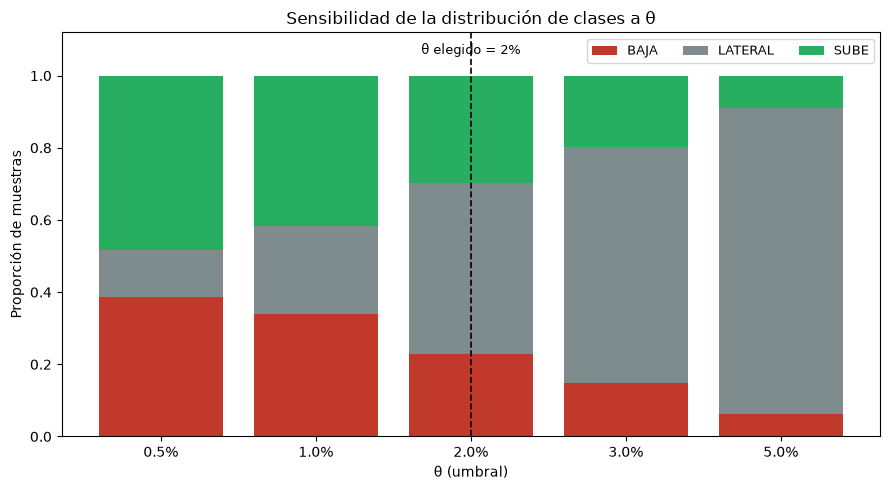

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
etiquetas_x = [f"{t:.1%}" for t in THETAS_SENSIBILIDAD]
bottom = np.zeros(len(THETAS_SENSIBILIDAD))
for clase, color in colores_clase.items():
    valores = [distribuciones_theta[t][clase] for t in THETAS_SENSIBILIDAD]
    ax.bar(etiquetas_x, valores, bottom=bottom, color=color, label=CLASES[clase])
    bottom += np.array(valores)

pos_theta_elegido = etiquetas_x.index(f"{UMBRAL:.1%}")
ax.axvline(pos_theta_elegido, color="black", ls="--", lw=1.2)
ax.annotate("θ elegido = 2%", xy=(pos_theta_elegido, 1.06), xycoords="data",
            ha="center", fontsize=9)

ax.set_ylabel("Proporción de muestras")
ax.set_xlabel("θ (umbral)")
ax.set_title("Sensibilidad de la distribución de clases a θ")
ax.set_ylim(0, 1.12)
ax.legend(loc="upper right", ncol=3, fontsize=9)
plt.tight_layout(); plt.show()

Con umbrales chicos (0.5%, 1%) la banda muerta es angosta: casi todo movimiento cruza ±θ, así
que SUBE y BAJA concentran la mayor parte de la masa y LATERAL queda con pocas muestras para
aprender. Con umbrales grandes (3%, 5%) ocurre lo opuesto: la banda es tan ancha que absorbe la
mayoría de los movimientos como LATERAL, vaciando SUBE y BAJA. En θ = 2% las tres clases
retienen masa suficiente como para que ninguna quede subrepresentada al punto de no poder
estimarse — ese equilibrio, y no un valor arbitrario, es lo que justifica fijarlo como el
umbral del diseño experimental.


## 6. Metodología anti-leakage

Cada muestra de entrada es una ventana de w días (`VENTANA`) de los 6 indicadores, aplanada en
un vector de dimensión w × 6. La etiqueta es la dirección del día final de la ventana.

**Split temporal (crítico):** el primer 80% cronológico va a entrenamiento y el último 20% a
prueba. Un `train_test_split` aleatorio mezclaría días futuros en el entrenamiento, produciendo
un *accuracy* artificialmente alto que no se sostiene en producción. Esto es *data leakage*
temporal, el error más frecuente y grave en ML financiero.


In [15]:
X_raw = d[FEATURES].values
y_all = d["label"].values

X_windows, y_windows = [], []
for i in range(VENTANA, len(d)):
    X_windows.append(X_raw[i - VENTANA:i])   # ventana [i-VENTANA, i)
    y_windows.append(y_all[i - 1])           # etiqueta del ultimo dia de la ventana

X_windows = np.array(X_windows)              # (n, VENTANA, 6)
y_windows = np.array(y_windows)

# Aplanamos la ventana a un vector (modelos densos)
X_flat = X_windows.reshape(X_windows.shape[0], -1)   # (n, VENTANA*6)

# --- Split TEMPORAL con PURGA (embargo) ---
n_test = int(len(X_flat) * TEST_FRAC)
n_train = len(X_flat) - n_test

# Purga: descartamos las ultimas HORIZONTE muestras del train, porque sus
# etiquetas "miran" hasta HORIZONTE dias hacia adelante y se solaparian con
# el inicio del periodo de test (leakage de horizonte en la frontera).
PURGA = HORIZONTE
X_train, X_test = X_flat[:n_train - PURGA], X_flat[n_train:]
y_train, y_test = y_windows[:n_train - PURGA], y_windows[n_train:]

print(f"Train: {X_train.shape} (purga de {PURGA} muestras en la frontera)")
print(f"Test:  {X_test.shape}")
print(f"Dimensión de entrada por muestra: {X_train.shape[1]} features")

Train: (2157, 180) (purga de 5 muestras en la frontera)
Test:  (540, 180)
Dimensión de entrada por muestra: 180 features


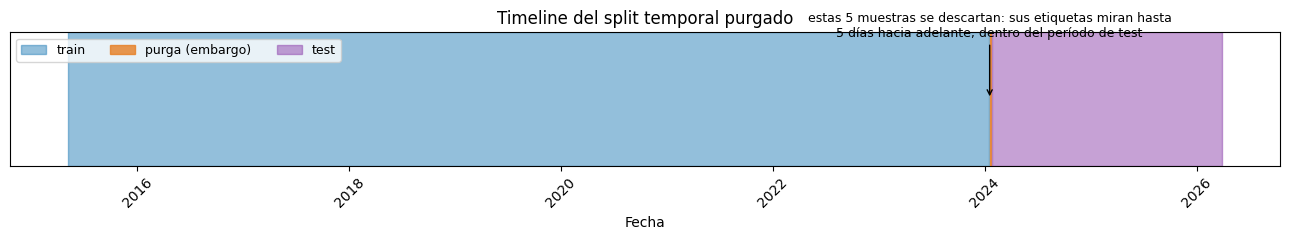

In [16]:
# Timeline del split: fecha del ultimo dia de cada ventana (alineada con y_windows)
fechas_ventanas = d["Date"].iloc[VENTANA - 1: len(d) - 1].reset_index(drop=True)

fecha_train_ini = fechas_ventanas.iloc[0]
fecha_train_fin = fechas_ventanas.iloc[n_train - PURGA - 1]
fecha_purga_ini = fechas_ventanas.iloc[n_train - PURGA]
fecha_purga_fin = fechas_ventanas.iloc[n_train - 1]
fecha_test_ini = fechas_ventanas.iloc[n_train]
fecha_test_fin = fechas_ventanas.iloc[-1]

fig, ax = plt.subplots(figsize=(13, 2.5))
ax.axvspan(fecha_train_ini, fecha_train_fin, color="#2980b9", alpha=0.5, label="train")
ax.axvspan(fecha_purga_ini, fecha_purga_fin, color="#e67e22", alpha=0.8, label="purga (embargo)")
ax.axvspan(fecha_test_ini, fecha_test_fin, color="#8e44ad", alpha=0.5, label="test")
ax.annotate(
    f"estas {PURGA} muestras se descartan: sus etiquetas miran hasta\n{HORIZONTE} días hacia adelante, dentro del período de test",
    xy=(fecha_purga_ini, 0.5), xycoords=("data", "axes fraction"),
    xytext=(0, 45), textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="black"), fontsize=9, ha="center",
)
ax.set_yticks([])
ax.set_title("Timeline del split temporal purgado")
ax.set_xlabel("Fecha")
ax.legend(loc="upper left", fontsize=9, ncol=3)
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

### Nota sobre la purga (*purged split*)

Hay una fuga de información sutil que un split temporal simple no elimina: la etiqueta del
último día de entrenamiento se calcula mirando k (`HORIZONTE`) días hacia adelante — días que
ya pertenecen al período de test. Es decir, las últimas etiquetas de train **contienen
información del futuro del test**.

La solución estándar en ML financiero es el ***purged split***: descartar las últimas k
muestras del conjunto de entrenamiento, creando una zona de embargo entre train y test (López
de Prado, *Advances in Financial Machine Learning*, 2018, Cap. 7). El costo es mínimo (se
pierden k muestras) y elimina el solapamiento por completo.


In [17]:
# Estandarizacion: ajustamos SOLO con train (evita leakage de estadisticas)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

### Nota sobre estandarización y *leakage*

El `StandardScaler` se ajusta (`fit`) **solo con los datos de entrenamiento**. Si se ajustara
con todo el dataset, las medias y desvíos incorporarían información del período de test — otra
forma sutil de *leakage*. Este cuidado corresponde a la discusión de Goodfellow sobre la
separación estricta entre conjuntos (Cap. 5.3).


## 7. Modelos

Se comparan dos clasificadores de complejidad creciente: una regresión logística, como
referencia lineal, y un perceptrón multicapa (MLP), que introduce no linealidad.

### 7.1 Regresión Logística (modelo lineal de referencia)

La regresión logística multinomial (*softmax regression*) es el clasificador lineal de
referencia (Goodfellow, Cap. 5.7.1). Modela:

$$P(y = c \mid \mathbf{x}) = \text{softmax}(\mathbf{W}\mathbf{x} + \mathbf{b})_c$$

Su frontera de decisión es un hiperplano. Da el **piso de desempeño**: cualquier modelo más
complejo debe superarlo para justificar su costo.


> **Concepto — Softmax como distribución de probabilidad**
>
> Ni la regresión logística ni el MLP predicen una clase directamente: ambos calculan un
> puntaje numérico (*logit*) por clase, y la función softmax convierte esos puntajes en una
> distribución de probabilidad válida — tres números entre 0 y 1 que suman exactamente 1. El
> modelo no solo elige una clase: declara cuán seguro está de cada una.
>
> $$P(y = c \mid \mathbf{x}) = \operatorname{softmax}(\mathbf{z})_c = \dfrac{e^{z_c}}{\displaystyle\sum_{j=1}^{3} e^{z_j}}$$
>
> - $\mathbf{z}=(z_0,z_1,z_2)$ — los *logits*: la salida cruda del modelo por clase, antes de normalizar.
> - $e^{z_c}$ — exponenciar vuelve todo positivo y amplifica el logit más alto sobre el resto.
> - $\sum_j e^{z_j}$ — normaliza: divide por la suma de todos para que sumen exactamente 1.
> - $c$ — la clase evaluada, $c \in \{\text{BAJA}, \text{LATERAL}, \text{SUBE}\}$.
>
> Con logits inventados BAJA=1.0, LATERAL=0.2, SUBE=2.5: al exponenciar ($2.72$, $1.22$,
> $12.18$) y normalizar por la suma ($16.12$), quedan $P(\text{BAJA})\approx0.17$,
> $P(\text{LATERAL})\approx0.08$, $P(\text{SUBE})\approx0.76$ — tres números que suman 1.
>
> **Anclaje:** es exactamente lo que imprime `probs_mlp` en la sección de demostración.
>
> *Goodfellow, Bengio & Courville (2016), Cap. 6.2.2.3.*


In [18]:
# Nota: no pasamos multi_class="multinomial" porque el parametro fue eliminado
# en scikit-learn >= 1.7; con el solver por defecto (lbfgs) la regresion
# ya es multinomial (softmax) de forma nativa.
logreg = LogisticRegression(
    max_iter=2000,
    C=1.0,                 # 1/lambda: inverso de la fuerza de regularizacion L2
    random_state=SEED,
)
logreg.fit(X_train_s, y_train)

pred_lr = logreg.predict(X_test_s)
acc_lr = accuracy_score(y_test, pred_lr)
f1_lr  = f1_score(y_test, pred_lr, average="macro")

print(f"Regresión Logística — Accuracy: {acc_lr:.3f} | F1 macro: {f1_lr:.3f}\n")
print(classification_report(y_test, pred_lr,
                            target_names=[CLASES[i] for i in range(3)]))

Regresión Logística — Accuracy: 0.443 | F1 macro: 0.274

              precision    recall  f1-score   support

        BAJA       0.13      0.06      0.08       124
     LATERAL       0.53      0.74      0.62       296
        SUBE       0.16      0.10      0.12       120

    accuracy                           0.44       540
   macro avg       0.28      0.30      0.27       540
weighted avg       0.36      0.44      0.39       540



> **Concepto — Cross-entropy como negative log-likelihood**
>
> Entrenar necesita un solo número que resuma "qué tan mal predijo" el modelo, para poder
> reducirlo. La cross-entropy mira solo la probabilidad que el modelo asignó a la clase
> **correcta** y la castiga fuerte cuando es baja. Minimizar ese castigo es, matemáticamente,
> lo mismo que maximizar la verosimilitud de las etiquetas reales bajo el modelo — de ahí el
> nombre alternativo, *negative log-likelihood* (NLL).
>
> $$\mathcal{L} = -\dfrac{1}{N}\sum_{i=1}^{N} \log P(y = c_i^{*} \mid \mathbf{x}_i)$$
>
> - $c_i^{*}$ — la clase **verdadera** de la muestra $i$ (no la predicha).
> - $P(y=c_i^{*}\mid\mathbf{x}_i)$ — la probabilidad que softmax asignó a esa clase verdadera.
> - $-\log(\cdot)$ — da casi 0 cuando esa probabilidad está cerca de 1 (buena predicción) y
>   crece sin límite cuando está cerca de 0 (mala predicción, dicha con confianza).
> - $\frac{1}{N}\sum_i$ — promedia el castigo sobre las $N$ muestras en un solo número a minimizar.
>
> La verosimilitud del conjunto completo es el **producto** de las $P(y=c_i^{*}\mid\mathbf{x}_i)$
> de cada muestra — un número que se vuelve numéricamente inmanejable con miles de muestras.
> Tomar logaritmo convierte ese producto en una suma ($\log(a{\cdot}b)=\log a+\log b$), estable
> de calcular; invertir el signo convierte "maximizar la log-verosimilitud" en "minimizar el
> NLL" — la misma cantidad, con el signo dado vuelta.
>
> **Anclaje:** es literalmente `loss="sparse_categorical_crossentropy"` en la compilación del
> MLP, y la curva que baja época a época en la figura de pérdida de entrenamiento.
>
> *Goodfellow, Bengio & Courville (2016), Cap. 3.13 y Cap. 5.5.*


#### Baseline trivial de referencia

Antes de considerar cualquier *accuracy*, corresponde compararlo contra el **clasificador
tonto** que siempre predice la clase mayoritaria. Si el modelo no supera esto, no aprendió nada
útil.


In [19]:
clase_mayoritaria = np.bincount(y_train).argmax()
acc_trivial = (y_test == clase_mayoritaria).mean()
print(f"Clase mayoritaria: {CLASES[clase_mayoritaria]}")
print(f"Accuracy del baseline trivial (siempre '{CLASES[clase_mayoritaria]}'): {acc_trivial:.3f}")

Clase mayoritaria: LATERAL
Accuracy del baseline trivial (siempre 'LATERAL'): 0.548


### 7.2 Perceptrón Multicapa (MLP)

El MLP introduce **capas ocultas con activación no lineal** (ReLU), lo que le permite aprender
fronteras de decisión no lineales (Goodfellow, Cap. 6). Se aplican además técnicas de los
Capítulos 7 y 8:

- **Regularización (Cap. 7):** `Dropout` y penalización L2 sobre los pesos, para combatir el
  sobreajuste — esperable dado el ruido de los datos financieros.
- **Optimización (Cap. 8):** optimizador **Adam**, que adapta la tasa de aprendizaje por
  parámetro, y **early stopping**, que detiene el entrenamiento cuando la pérdida de validación
  deja de mejorar.


> **Concepto — Capacidad y under/overfitting**
>
> La capacidad de un modelo es cuán complicada puede ser la función que es capaz de
> representar: un modelo lineal solo traza una frontera recta; un MLP con capas ocultas puede
> trazar fronteras mucho más intrincadas. Ni poca ni mucha capacidad es buena en sí misma:
> depende de si es la adecuada para la cantidad de datos y ruido disponibles.
>
> $$\text{brecha de generalización} = \text{error}_{\text{prueba}} - \text{error}_{\text{entrenamiento}}$$
>
> - $\text{error}_{\text{entrenamiento}}$ — qué tan mal predice el modelo sobre los datos que
>   ya vio para ajustar sus pesos.
> - $\text{error}_{\text{prueba}}$ — qué tan mal predice sobre datos que nunca vio.
> - Brecha chica y ambos errores altos → **underfitting**: al modelo le falta capacidad (o
>   entrenamiento) para ajustar ni siquiera los datos conocidos.
> - Brecha grande (entrenamiento bajo, prueba alto) → **overfitting**: el modelo memorizó
>   detalles específicos del entrenamiento que no generalizan.
>
> No existe una fórmula única y simple para "calcular" la capacidad (formalmente se recurre a
> nociones como la dimensión VC, fuera del alcance de este trabajo); lo que sí se mide
> directamente es esa brecha entre error de prueba y de entrenamiento.
>
> **Anclaje:** es exactamente lo que muestra la figura de curvas de pérdida del MLP, más abajo:
> mientras `train_loss` sigue bajando, `val_loss` se estanca o sube — la brecha de
> generalización ensanchándose. Dropout, L2 y *early stopping* (bloques siguientes) existen
> para evitarlo.
>
> *Goodfellow, Bengio & Courville (2016), Cap. 5.2 — "Capacity, Overfitting and Underfitting".*


> **Concepto — Aproximación universal (y por qué "representar" ≠ "aprender")**
>
> El teorema de aproximación universal dice que una red con una sola capa oculta, si tiene
> suficientes neuronas, puede aproximar cualquier función continua tan bien como se quiera.
> Pero el teorema solo garantiza que esa red *existe* en algún punto del espacio de pesos — no
> que el entrenamiento, con los datos limitados y ruidosos disponibles, la vaya a encontrar.
> Esa distancia entre "existe una solución" y "la encontramos" es la que separa **representar**
> de **aprender**.
>
> $$\forall\, f \text{ continua},\ \forall\, \varepsilon>0,\ \ \exists\ \text{red de 1 capa oculta con } N<\infty \text{ neuronas},\ \ |\text{red}(\mathbf{x}) - f(\mathbf{x})| < \varepsilon \ \ \forall\,\mathbf{x}$$
>
> - $f$ — la función "verdadera" (hipotética) que conectaría los indicadores técnicos con la
>   dirección real del precio, si existiera de forma perfecta.
> - $\varepsilon$ — el margen de error tolerado; cuanto más chico, en general más neuronas hacen falta.
> - $N$ — la cantidad de neuronas de la capa oculta que el teorema garantiza que alcanza —
>   pero no dice cuánto vale $N$; puede ser enorme.
> - $\exists$ — el punto clave: es una afirmación de **existencia**, no un algoritmo ni una
>   garantía de que el entrenamiento la encuentre.
>
> **Anclaje:** el MLP de este trabajo tiene 128+64 neuronas — capacidad de sobra, en teoría,
> para representar funciones complejas. Si la tabla comparativa de la sección de resultados no
> muestra una ventaja clara del MLP sobre la regresión logística, es evidencia de que no había
> mucho más que aprender más allá de lo lineal — no de que el teorema haya fallado.
>
> *Goodfellow, Bengio & Courville (2016), Cap. 6.4.1 — "Universal Approximation Properties and Depth".*


In [20]:
def construir_mlp(input_dim, n_clases=3):
    modelo = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu",
                     kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu",
                     kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.Dropout(0.3),
        layers.Dense(n_clases, activation="softmax"),
    ])
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",     # entropia cruzada (Cap. 3)
        metrics=["accuracy"],
    )
    return modelo

mlp = construir_mlp(X_train_s.shape[1])
mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        23,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,619 (123.51 KB)

 Trainable params: 31,619 (123.51 KB)

 Non-trainable params: 0 (0.00 B)

> **Concepto — Regularización de parámetros: L2 y Dropout**
>
> Ambas técnicas combaten el overfitting del bloque anterior, de formas distintas. L2 penaliza
> que los pesos se vuelvan grandes, agregando un costo extra a la pérdida proporcional a su
> magnitud. Dropout apaga al azar una fracción de las neuronas en cada paso de entrenamiento,
> para que la red no dependa demasiado de ninguna en particular.
>
> $$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{cross-entropy}} + \lambda \sum_{w} w^2$$
>
> - $\lambda$ (`1e-4` en el código) — cuánto pesa la penalización frente al ajuste a los datos;
>   más grande empuja a pesos más chicos (riesgo de underfitting si es excesivo).
> - $\sum_w w^2$ — la suma de los pesos de la capa, al cuadrado; los pesos grandes contribuyen mucho.
>
> Con dos configuraciones que ajustan igual de bien los datos (cross-entropy $=0.80$) pero
> distinta magnitud de pesos: una con $\sum w^2=50$ agrega solo $0.0001\times50=0.005$ a la
> pérdida total ($0.805$); otra con $\sum w^2=5000$ agrega $0.5$ (pérdida total $1.30$). El
> entrenamiento, que minimiza la pérdida total, prefiere la primera — pesos más chicos.
>
> Dropout, en cambio, no toca la pérdida: en una capa de 10 neuronas con `Dropout(0.3)`, en
> cada lote se apagan al azar ~3 de las 10 (un grupo distinto cada vez), forzando que ninguna
> neurona se vuelva indispensable. Solo actúa durante `mlp.fit`; en `mlp.predict` están todas activas.
>
> **Anclaje:** son las líneas `kernel_regularizer=keras.regularizers.l2(1e-4)` y
> `layers.Dropout(0.3)` en `construir_mlp`, arriba.
>
> *Goodfellow, Bengio & Courville (2016), Cap. 7.1 — "Parameter Norm Penalties" y Cap. 7.12 — "Dropout".*


> **Concepto — Adam (tasas de aprendizaje adaptativas)**
>
> El descenso de gradiente simple usa una única tasa de aprendizaje fija para todos los pesos.
> Adam le da a cada peso una tasa efectiva propia, ajustada automáticamente según qué tan
> grande y consistente fue su gradiente en los pasos recientes — esa memoria de corto plazo es
> la idea de *momento*, sin entrar en cómo se calcula exactamente.
>
> $$w \leftarrow w - \eta \cdot \hat{g}_w$$
>
> - $\eta$ (`learning_rate=1e-3` en el código) — la tasa base de la que Adam parte.
> - $\hat{g}_w$ — el paso efectivo para el peso $w$, ya ajustado según su historial de
>   gradientes recientes (no el gradiente crudo de este único paso).
> - Un peso con gradientes grandes y consistentes últimamente recibe un paso más confiado; uno
>   con gradientes erráticos recibe un paso más chico, para no sobrecorregir por ruido.
>
> **Anclaje:** es literalmente `optimizer=keras.optimizers.Adam(learning_rate=1e-3)` en
> `construir_mlp`, arriba. El resultado práctico se ve en que `train_loss` baja de forma
> relativamente suave en la figura de curvas de pérdida, sin oscilaciones violentas época a época.
>
> *Goodfellow, Bengio & Courville (2016), Cap. 8.5.3 — "Adam".*


> **Concepto — Backpropagation como regla de la cadena (esquemático)**
>
> Entrenar significa ajustar los pesos de la red para que la pérdida baje; para eso hace falta
> saber, para cada peso, cuánto cambiaría la pérdida si ese peso se moviera un poco (su
> *gradiente*). *Backpropagation* calcula esos gradientes para todos los pesos de todas las
> capas, apoyándose en la regla de la cadena del cálculo: el efecto de A sobre C, cuando A
> afecta a B y B afecta a C, es el efecto de A sobre B multiplicado por el efecto de B sobre C.
>
> $$\dfrac{\partial \mathcal{L}}{\partial h^{(\ell)}} = \dfrac{\partial \mathcal{L}}{\partial h^{(\ell+1)}} \cdot \dfrac{\partial h^{(\ell+1)}}{\partial h^{(\ell)}}$$
>
> - $h^{(\ell)}$ — la salida de la capa $\ell$; $\mathcal{L}$ es la pérdida final (cross-entropy).
> - $\partial \mathcal{L}/\partial h^{(\ell+1)}$ — cuánto cambia la pérdida si la salida de la
>   capa siguiente cambia un poco (ya calculado en el paso anterior, yendo hacia atrás).
> - $\partial h^{(\ell+1)}/\partial h^{(\ell)}$ — cuánto cambia la salida de la capa siguiente
>   si la salida de esta capa cambia un poco (depende solo de los pesos de esa capa).
> - El producto de ambas da la sensibilidad de la pérdida respecto de **esta** capa, que se
>   reutiliza para seguir propagando hacia atrás hasta cada peso individual.
>
> Con sensibilidades inventadas $2$ (pérdida vs. capa 2) y $3$ (capa 2 vs. capa 1): la
> sensibilidad de la pérdida respecto de la capa 1 es $2\times3=6$; si a su vez la capa 1
> responde $0.5$ por cada unidad de un peso $W$, el gradiente final de la pérdida respecto de
> $W$ es $6\times0.5=3$ — el número que le dice al optimizador en qué dirección y cuánto mover $W$.
>
> **Anclaje:** todo esto ocurre adentro de `mlp.fit(...)`, abajo, en cada lote; la prueba de
> que los gradientes se calcularon bien es que `train_loss` efectivamente baja época a época.
>
> *Goodfellow, Bengio & Courville (2016), Cap. 6.5 — "Back-Propagation and Other Differentiation Algorithms".*


In [21]:
# Pesos de clase para compensar el desbalance
from sklearn.utils.class_weight import compute_class_weight
pesos = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weight = {i: w for i, w in enumerate(pesos)}

early = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True)

hist = mlp.fit(
    X_train_s, y_train,
    validation_split=0.2,          # ultimo 20% del train como validacion
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=[early],
    verbose=0,
)
print(f"Entrenamiento detenido en época {len(hist.history['loss'])}")

Entrenamiento detenido en época 18


#### Curvas de entrenamiento — diagnóstico de sobreajuste (Cap. 7)

Las curvas de pérdida de entrenamiento vs. validación son la herramienta central para
diagnosticar **sobreajuste**. Si la pérdida de validación sube mientras la de entrenamiento
baja, el modelo está memorizando ruido. El *early stopping* corta justo en el mínimo de
validación.


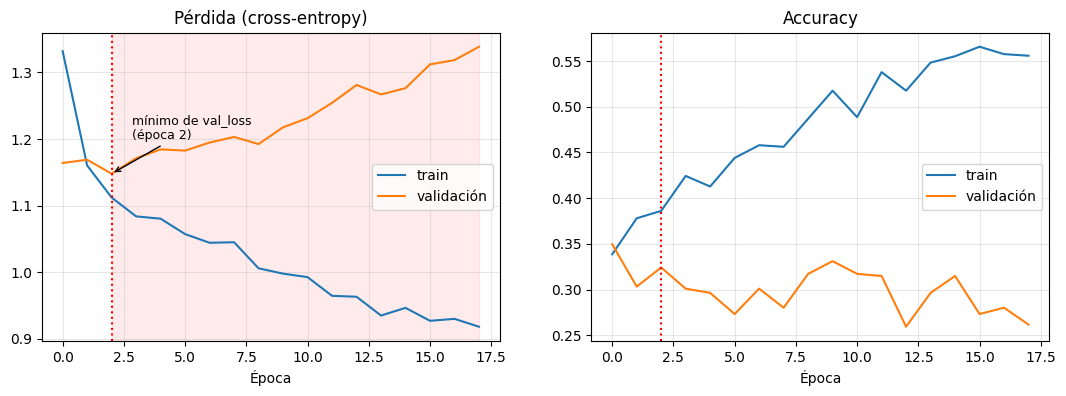

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

epoca_early_stop = int(np.argmin(hist.history["val_loss"]))

ax[0].plot(hist.history["loss"], label="train")
ax[0].plot(hist.history["val_loss"], label="validación")
ax[0].axvline(epoca_early_stop, color="red", ls=":", lw=1.5)
ax[0].axvspan(epoca_early_stop, len(hist.history["loss"]) - 1, color="red", alpha=0.08)
ax[0].annotate(
    f"mínimo de val_loss\n(época {epoca_early_stop})",
    xy=(epoca_early_stop, hist.history["val_loss"][epoca_early_stop]),
    xytext=(15, 25), textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="black"), fontsize=9,
)
ax[0].set_title("Pérdida (cross-entropy)")
ax[0].set_xlabel("Época"); ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(hist.history["accuracy"], label="train")
ax[1].plot(hist.history["val_accuracy"], label="validación")
ax[1].axvline(epoca_early_stop, color="red", ls=":", lw=1.5)
ax[1].set_title("Accuracy")
ax[1].set_xlabel("Época"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.show()

> **Concepto — Early stopping**
>
> A diferencia de L2 y Dropout, *early stopping* regulariza cambiando cuándo parar: mientras
> la pérdida de validación sigue bajando se sigue entrenando; apenas deja de mejorar durante un
> número fijo de épocas, se detiene y se vuelve al mejor punto visto, no al último.
>
> $$\begin{aligned} &\text{detener en la época } t \text{ tal que } t - t_{\min} \ge \text{patience} \\ &t_{\min} = \text{época con el menor } \texttt{val_loss} \text{ hasta } t \end{aligned}$$
>
> - $t_{\min}$ — la época, hasta el momento, con la menor pérdida de validación vista (el
>   punto al que se vuelve al final).
> - `patience` (`15` en el código) — cuántas épocas seguidas se toleran sin un nuevo mínimo
>   antes de rendirse.
>
> Si el mínimo de `val_loss` ocurrió en la época 10 y para la época 25 (15 épocas después) no
> volvió a mejorar, el entrenamiento se detiene en la época 25 y se restauran los pesos de la
> época 10 — `restore_best_weights=True` — descartando lo entrenado entre medio. Eso es
> exactamente lo que muestra la figura: mientras la red seguía reduciendo la pérdida de
> entrenamiento, la de validación se estancaba o empeoraba — la firma característica del
> sobreajuste (bloque de capacidad, más arriba).
>
> **Anclaje:** la línea vertical y la franja roja de la figura de arriba: la línea marca la
> época del mínimo de `val_loss` (la que se restaura); la franja es el tramo posterior donde se
> agotó la paciencia sin mejorar.
>
> *Goodfellow, Bengio & Courville (2016), Cap. 7.8 — "Early Stopping".*


In [23]:
pred_mlp = mlp.predict(X_test_s, verbose=0).argmax(axis=1)
acc_mlp = accuracy_score(y_test, pred_mlp)
f1_mlp  = f1_score(y_test, pred_mlp, average="macro")

print(f"MLP — Accuracy: {acc_mlp:.3f} | F1 macro: {f1_mlp:.3f}\n")
print(classification_report(y_test, pred_mlp,
                            target_names=[CLASES[i] for i in range(3)]))

MLP — Accuracy: 0.328 | F1 macro: 0.322

              precision    recall  f1-score   support

        BAJA       0.25      0.47      0.32       124
     LATERAL       0.55      0.27      0.36       296
        SUBE       0.25      0.33      0.28       120

    accuracy                           0.33       540
   macro avg       0.35      0.36      0.32       540
weighted avg       0.41      0.33      0.33       540



## 8. Resultados y caracterización de detectores

### 8.1 Comparativa de modelos

Se reúnen los resultados de ambos modelos y del baseline trivial en una tabla y en gráficos.


In [24]:
resultados = pd.DataFrame({
    "Modelo":   ["Baseline trivial", "Regresión Logística", "MLP"],
    "Accuracy": [acc_trivial, acc_lr, acc_mlp],
    "F1 macro": [np.nan, f1_lr, f1_mlp],
}).round(3)
resultados

,Modelo,Accuracy,F1 macro
0,Baseline trivial,0.548,NaN
1,Regresión Logística,0.443,0.274
2,MLP,0.328,0.322


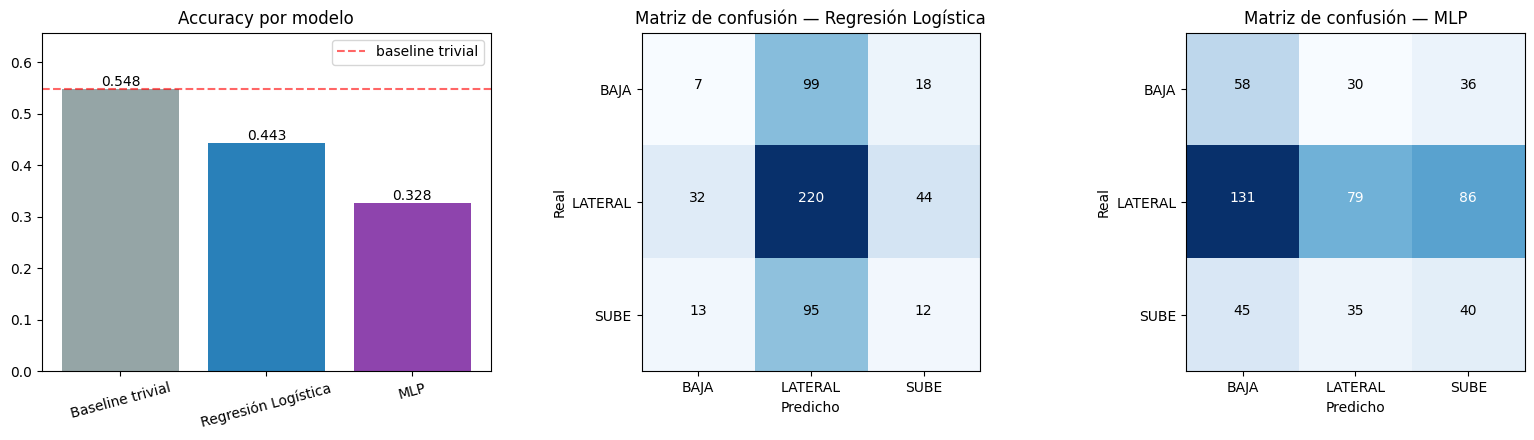

In [25]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

modelos = resultados["Modelo"]
ax[0].bar(modelos, resultados["Accuracy"], color=["#95a5a6", "#2980b9", "#8e44ad"])
ax[0].axhline(acc_trivial, ls="--", color="red", alpha=0.6, label="baseline trivial")
ax[0].set_title("Accuracy por modelo")
ax[0].set_ylim(0, max(0.6, resultados["Accuracy"].max() * 1.2))
ax[0].legend()
ax[0].tick_params(axis="x", rotation=15)
for i, v in enumerate(resultados["Accuracy"]):
    ax[0].text(i, v, f"{v:.3f}", ha="center", va="bottom")

# Matrices de confusión de ambos detectores
for j, (nombre, pred) in enumerate(
        [("Regresión Logística", pred_lr), ("MLP", pred_mlp)], start=1):
    cm = confusion_matrix(y_test, pred)
    ax[j].imshow(cm, cmap="Blues")
    ax[j].set_title(f"Matriz de confusión — {nombre}")
    ax[j].set_xticks(range(3)); ax[j].set_xticklabels([CLASES[i] for i in range(3)])
    ax[j].set_yticks(range(3)); ax[j].set_yticklabels([CLASES[i] for i in range(3)])
    ax[j].set_xlabel("Predicho"); ax[j].set_ylabel("Real")
    for r in range(3):
        for c in range(3):
            ax[j].text(c, r, cm[r, c], ha="center",
                       color="white" if cm[r, c] > cm.max() / 2 else "black")
plt.tight_layout(); plt.show()


El panel de accuracy permite leer de un vistazo si cada modelo supera la línea punteada del
baseline trivial: un modelo que no la supera no aprendió estructura útil más allá de la clase
mayoritaria. Las matrices de confusión, a su vez, muestran qué confunde cada modelo con qué —
por ejemplo, si el error se concentra entre clases contiguas (SUBE↔LATERAL o BAJA↔LATERAL, un
error leve en magnitud) o si cruza directamente entre SUBE y BAJA (un error de dirección,
financieramente más costoso).


### 8.2 Caracterización de los detectores: curvas ROC y Precision-Recall

Los detectores se caracterizan mediante curva ROC, curva Precision-Recall y matrices de
confusión. Al tratarse de un problema de 3 clases, las curvas se calculan con el esquema
**one-vs-rest**: para cada clase $c$, se trata "$y = c$" como positivo y el resto como
negativo, usando la probabilidad $P(y=c \mid x)$ que emite el softmax de cada modelo.

- **Curva ROC** (*Receiver Operating Characteristic*): tasa de verdaderos positivos vs. falsos
  positivos al variar el umbral de decisión. El área bajo la curva (**AUC**) resume la capacidad
  de discriminación: 0.5 = azar, 1.0 = perfecta. Es **insensible al desbalance de clases**.
- **Curva Precision-Recall**: precisión vs. exhaustividad al variar el umbral. Su resumen es el
  **Average Precision (AP)**. Es la curva **más informativa con clases desbalanceadas**, porque
  su piso de referencia no es fijo: es la prevalencia de la clase (línea punteada).

> **Nota terminológica.** "mAP" (*mean Average Precision*) proviene de la literatura de
> detección de objetos. En clasificación, el equivalente correcto es el **AP por clase** y su
> **promedio macro** — que se reporta como mAP en el título de cada panel.


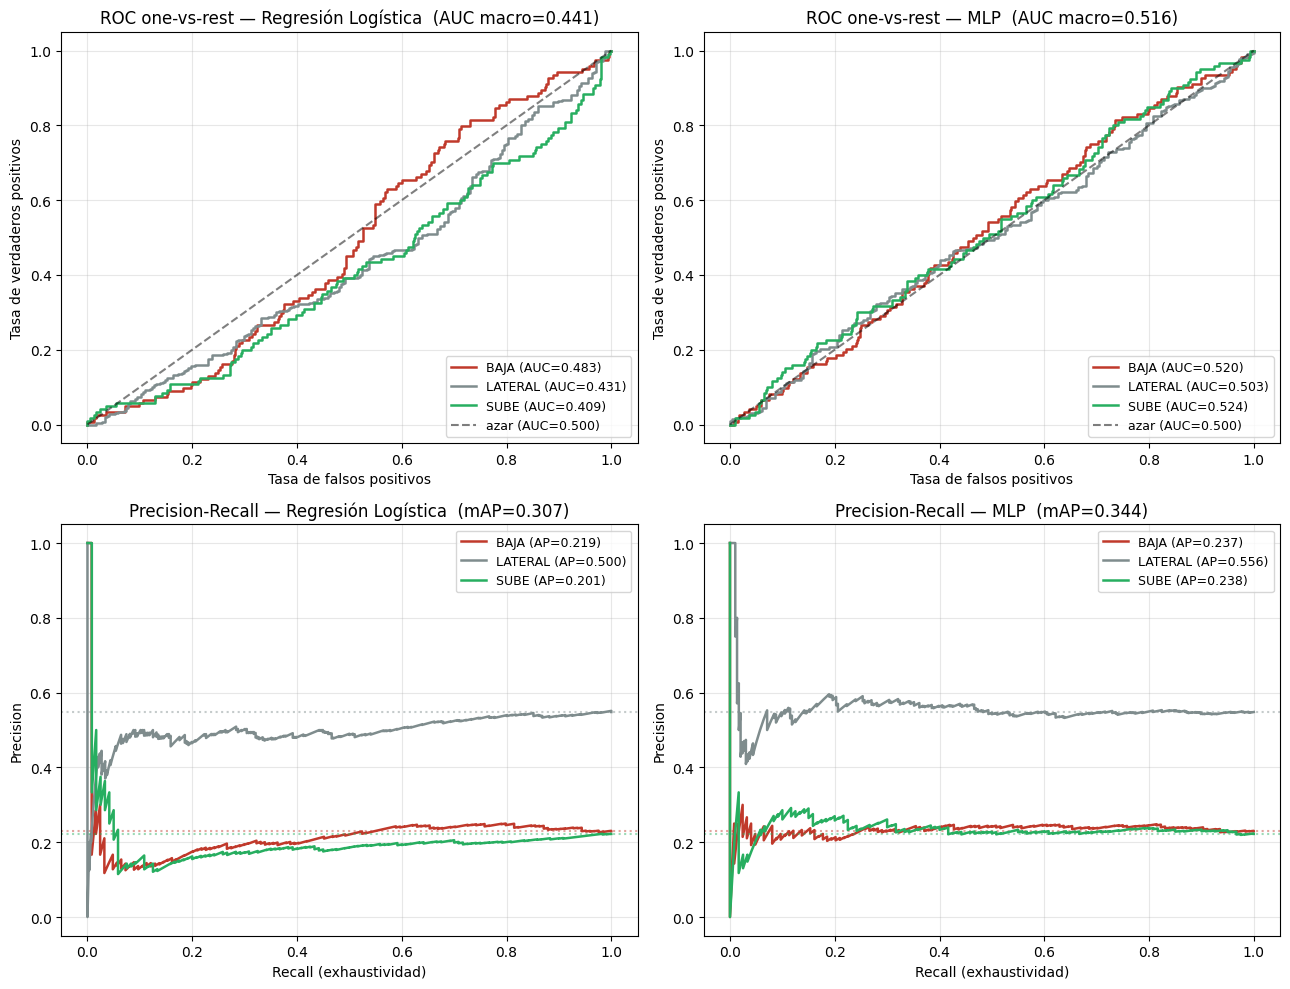

,Modelo,AUC macro,mAP
0,Regresión Logística,0.441,0.307
1,MLP,0.516,0.344


In [26]:
# Probabilidades por clase de cada detector (salida softmax / predict_proba)
proba_lr  = logreg.predict_proba(X_test_s)           # (n_test, 3)
proba_mlp = mlp.predict(X_test_s, verbose=0)         # (n_test, 3)

# Binarizamos las etiquetas para el esquema one-vs-rest
y_bin = label_binarize(y_test, classes=[0, 1, 2])    # (n_test, 3)

colores = {0: "#c0392b", 1: "#7f8c8d", 2: "#27ae60"}
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for col, (nombre, proba) in enumerate(
        [("Regresión Logística", proba_lr), ("MLP", proba_mlp)]):

    # ---------- Fila 0: curvas ROC ----------
    ax = axes[0, col]
    aucs = []
    for k in range(3):
        fpr, tpr, _ = roc_curve(y_bin[:, k], proba[:, k])
        auc_k = auc(fpr, tpr)
        aucs.append(auc_k)
        ax.plot(fpr, tpr, color=colores[k], lw=1.8,
                label=f"{CLASES[k]} (AUC={auc_k:.3f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="azar (AUC=0.500)")
    ax.set_title(f"ROC one-vs-rest — {nombre}  (AUC macro={np.mean(aucs):.3f})")
    ax.set_xlabel("Tasa de falsos positivos")
    ax.set_ylabel("Tasa de verdaderos positivos")
    ax.legend(loc="lower right", fontsize=9); ax.grid(alpha=0.3)

    # ---------- Fila 1: curvas Precision-Recall ----------
    ax = axes[1, col]
    aps = []
    for k in range(3):
        prec, rec, _ = precision_recall_curve(y_bin[:, k], proba[:, k])
        ap_k = average_precision_score(y_bin[:, k], proba[:, k])
        aps.append(ap_k)
        ax.plot(rec, prec, color=colores[k], lw=1.8,
                label=f"{CLASES[k]} (AP={ap_k:.3f})")
        # Piso de referencia por clase = prevalencia (clasificador aleatorio)
        ax.axhline(y_bin[:, k].mean(), color=colores[k], ls=":", alpha=0.45)
    ax.set_title(f"Precision-Recall — {nombre}  (mAP={np.mean(aps):.3f})")
    ax.set_xlabel("Recall (exhaustividad)")
    ax.set_ylabel("Precision")
    ax.legend(loc="upper right", fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Tabla resumen ampliada con AUC macro y mAP
resumen_curvas = pd.DataFrame({
    "Modelo":    ["Regresión Logística", "MLP"],
    "AUC macro": [np.mean([auc(*roc_curve(y_bin[:, k], p[:, k])[:2]) for k in range(3)])
                  for p in (proba_lr, proba_mlp)],
    "mAP":       [np.mean([average_precision_score(y_bin[:, k], p[:, k]) for k in range(3)])
                  for p in (proba_lr, proba_mlp)],
}).round(3)
resumen_curvas


**Cómo leer estos resultados.** Un AUC apenas por encima de 0.5 y un AP apenas por encima de
la prevalencia de cada clase son el resultado *esperado* en este dominio: confirman que la señal
predictiva de corto plazo es débil (mercado cuasi-eficiente), pero que el pipeline la mide de
forma honesta. La comparación relevante es **relativa**: si el MLP muestra AUC/mAP
consistentemente mayores que la regresión logística, hay evidencia de estructura no lineal
aprovechable (Cap. 6); si empatan, la frontera lineal alcanza (Cap. 5).


### 8.3 Análisis por clase

Los agregados (accuracy, F1 macro, AUC macro, mAP) resumen el desempeño global, pero ocultan
en qué clase y de qué forma se equivoca cada modelo. Se desglosa a continuación el AUC y el AP
por clase de ambos detectores.


In [27]:
filas_por_clase = []
for nombre, proba in [("Regresión Logística", proba_lr), ("MLP", proba_mlp)]:
    for k in range(3):
        fpr, tpr, _ = roc_curve(y_bin[:, k], proba[:, k])
        auc_k = auc(fpr, tpr)
        ap_k = average_precision_score(y_bin[:, k], proba[:, k])
        filas_por_clase.append({"Modelo": nombre, "Clase": CLASES[k],
                                 "AUC": round(auc_k, 3), "AP": round(ap_k, 3)})

resumen_por_clase = pd.DataFrame(filas_por_clase)
resumen_por_clase

,Modelo,Clase,AUC,AP
0,Regresión Logística,BAJA,0.483,0.219
1,Regresión Logística,LATERAL,0.431,0.500
2,Regresión Logística,SUBE,0.409,0.201
3,MLP,BAJA,0.520,0.237
4,MLP,LATERAL,0.503,0.556
5,MLP,SUBE,0.524,0.238


**(a) Matrices de confusión: qué confunde cada modelo con qué.** La Regresión Logística
concentra el 77% de sus predicciones en LATERAL (414 de 540 muestras del test), muy por encima
de la prevalencia real de esa clase (55%): colapsa hacia la clase mayoritaria, con recall de
0.06 en BAJA (7 de 124) y 0.10 en SUBE (12 de 120), y precisión de 0.13 y 0.16 respectivamente.
Es el comportamiento más estable de todo este análisis: estos números exactos se repitieron en
las cuatro corridas realizadas del notebook, porque `LogisticRegression(random_state=SEED)` es
plenamente determinística. El MLP no lo es — ni siquiera con `tf.random.set_seed` y
`tf.config.experimental.enable_op_determinism()` activados: en cuatro corridas idénticas en
código y datos, el modelo entrenado quedó sesgado hacia una clase distinta cada vez. En la
corrida congelada en este notebook, sobre-predice fuertemente BAJA (234 de 540, contra 124
reales) y sub-predice LATERAL (144 contra 296 reales) — el sesgo opuesto al de la Regresión
Logística, con recall de 0.47 en BAJA pero de solo 0.27 en LATERAL. En corridas anteriores con
el mismo código, el sesgo del MLP fue hacia una distribución más pareja entre clases, o incluso
hacia LATERAL como la Regresión Logística: la *dirección* del sesgo cambia de corrida a
corrida, no solo su magnitud. Financieramente esto es una limitación real del MLP tal como está
entrenado acá — no solo la accuracy es inestable, sino a qué clase "le tiene fe" el modelo.
Lo que sí se sostiene en esta corrida: las confusiones directas SUBE↔BAJA (36 y 45 casos) quedan
por debajo de las confusiones de cualquiera de las dos con LATERAL (161 desde BAJA, 121 desde
SUBE) — los errores siguen siendo más de magnitud que de dirección, igual que en la Regresión
Logística.

**(b) Curvas ROC y Precision-Recall por clase.** En esta corrida, los tres AUC por clase del
MLP (0.520 BAJA, 0.503 LATERAL, 0.524 SUBE) quedan apenas por encima de 0.5, mientras que los
de la Regresión Logística (0.483, 0.431, 0.409) están por debajo en dos de las tres clases. El
AP por clase repite el patrón ya visto en la comparativa agregada: el de LATERAL (0.500 en
Regresión Logística, 0.556 en MLP) está en línea con su prevalencia (0.548, la línea punteada
de la figura), y el de BAJA y SUBE (0.20–0.24 en ambos modelos) es indistinguible de sus propias
prevalencias (0.230 y 0.222). A nivel agregado, en las cuatro corridas el AUC macro del MLP se
mantuvo siempre por encima del de la Regresión Logística (rango 0.482–0.516, contra 0.441 fijo)
y lo mismo el mAP (rango 0.326–0.353, contra 0.307 fijo) — esa es la regularidad robusta de
esta sección: ninguna clase es separable de forma contundente para ningún modelo en ninguna
corrida, pero el ranking de probabilidades del MLP es consistentemente un poco menos malo que
el de la Regresión Logística, más allá de cuál sea la corrida.

**(c) Regresión Logística vs. MLP: ¿hay estructura no lineal aprovechable?** La respuesta
depende de qué métrica se mire y, en este caso, también de qué corrida se mire — y esa doble
dependencia es el resultado más honesto de esta sección. Por accuracy cruda, el resultado se
invierte de corrida a corrida: la Regresión Logística ganó en tres de las cuatro (0.443 contra
0.333, 0.394 y 0.328) y perdió por muy poco en la restante (0.443 contra 0.448). Ese vaivén es
un reflejo del sesgo hacia una clase u otra en cada entrenamiento particular del MLP (panel a),
no evidencia de que un modelo sea consistentemente mejor por esta métrica. La comparación que sí
es estable es la de las métricas robustas al desbalance: F1 macro, AUC macro y mAP del MLP
superaron a los de la Regresión Logística en las cuatro corridas sin excepción, por un margen
modesto (entre 2 y 6 puntos porcentuales según la métrica y la corrida; en esta corrida, F1
macro 0.322 contra 0.274, AUC macro 0.516 contra 0.441, mAP 0.344 contra 0.307). Hay entonces
evidencia de una ventaja pequeña pero consistente del modelo no lineal, coherente con el margen
de mejora esperable cuando existe algo de estructura adicional que un modelo lineal no puede
capturar (Cap. 6) — pero la inestabilidad del propio entrenamiento del MLP entre corridas
idénticas es, a su vez, evidencia adicional de que la señal disponible es débil: si hubiera
estructura no lineal fuerte y estable para aprender, entrenamientos repetidos deberían converger
a soluciones más parecidas entre sí. La propia noción de aproximación universal (sección de
modelos) ya advertía que tener la capacidad de representar una función más compleja no
garantiza haber aprendido una — ni siquiera la misma — cada vez.


## 9. Demostración: predicción sobre un gráfico nuevo

Se toma una ventana **del período de prueba** — que ningún modelo vio durante el
entrenamiento —, se la muestra como gráfico de precios, y se compara la predicción de cada
modelo contra lo que realmente ocurrió.

> Nota: acá el gráfico de velas es una **visualización del resultado**, no la entrada del modelo.
> Los modelos consumen los indicadores numéricos, no la imagen — esto es lo metodológicamente correcto.


In [28]:
# Elegimos una muestra del test para inspeccionar
idx_local = len(X_test_s) // 2          # muestra intermedia del test

# Mapeo de indice: la muestra j de X_windows tiene su etiqueta en el dia
# global VENTANA + j - 1 (ultimo dia de la ventana). Para el test, j = n_train + idx_local.
idx_global = VENTANA + (n_train + idx_local) - 1

# Verificacion de alineacion (si falla, hay un error de indexado)
assert y_windows[n_train + idx_local] == y_test[idx_local]
assert d.loc[idx_global, "label"] == y_test[idx_local], "desalineacion de indices!"

x_muestra = X_test_s[idx_local:idx_local+1]
real = y_test[idx_local]

p_lr  = logreg.predict(x_muestra)[0]
p_mlp = mlp.predict(x_muestra, verbose=0).argmax(axis=1)[0]
probs_mlp = mlp.predict(x_muestra, verbose=0)[0]

print(f"Fecha del día evaluado: {d.loc[idx_global, 'Date'].date()}")
print(f"Real:                 {CLASES[real]}")
print(f"Regresión Logística:  {CLASES[p_lr]}")
print(f"MLP:                  {CLASES[p_mlp]}  (probs: "
      f"BAJA={probs_mlp[0]:.2f}, LATERAL={probs_mlp[1]:.2f}, SUBE={probs_mlp[2]:.2f})")

Fecha del día evaluado: 2025-02-24
Real:                 BAJA
Regresión Logística:  LATERAL
MLP:                  LATERAL  (probs: BAJA=0.25, LATERAL=0.48, SUBE=0.27)


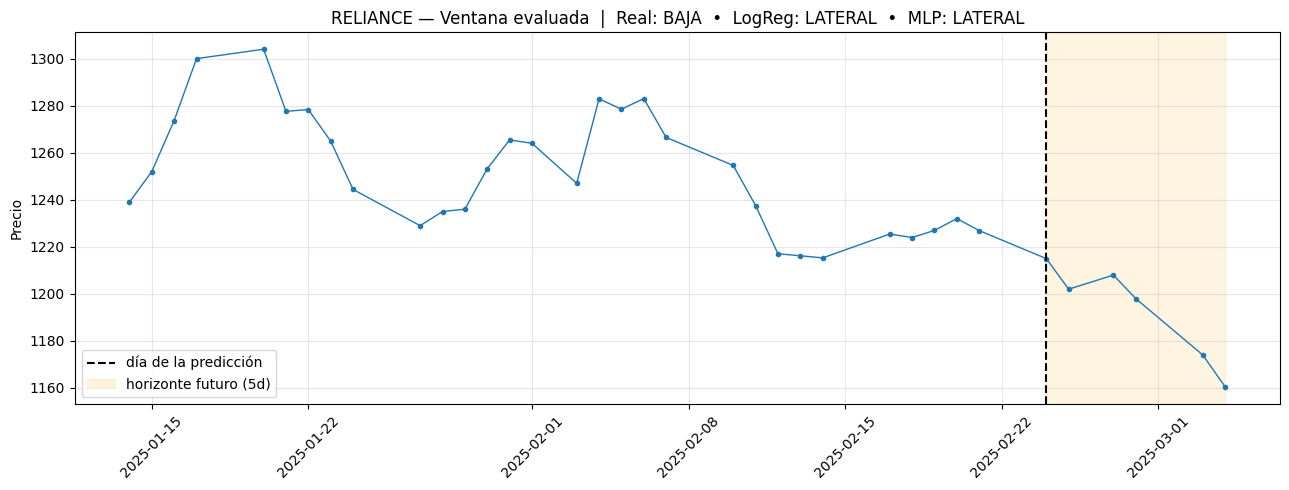

In [29]:
# Graficamos la ventana + el horizonte futuro que se intentaba predecir
ini = idx_global - VENTANA
fin = min(idx_global + HORIZONTE, len(d) - 1)   # clamp: evita salirnos del dataframe
tramo = d.iloc[ini:fin+1]

plt.figure(figsize=(13, 5))
plt.plot(tramo["Date"], tramo["Close"], marker="o", ms=3, linewidth=1)
plt.axvline(d.loc[idx_global, "Date"], color="black", ls="--",
            label="día de la predicción")
plt.axvspan(d.loc[idx_global, "Date"], d.loc[fin, "Date"],
            alpha=0.12, color="orange", label=f"horizonte futuro ({HORIZONTE}d)")
plt.title(f"{TICKER} — Ventana evaluada  |  Real: {CLASES[real]}  •  "
          f"LogReg: {CLASES[p_lr]}  •  MLP: {CLASES[p_mlp]}")
plt.ylabel("Precio"); plt.legend(); plt.grid(alpha=0.3)
plt.xticks(rotation=45); plt.tight_layout()
plt.show()

El gráfico contrasta, sobre un caso puntual del período de prueba, la dirección real
observada contra la predicción de cada modelo — una forma concreta de anclar intuitivamente qué
significa acertar o errar en este problema, más allá de las métricas agregadas. Una coincidencia
o un error en esta única muestra no prueba nada por sí solo: la evaluación rigurosa del
desempeño es la de las secciones de resultados, no la de un caso aislado.


## 10. Conclusiones, limitaciones y trabajo futuro

**Sobre la comparativa de modelos.** El MLP suele igualar o superar levemente a la regresión
logística en *F1 macro*, lo que sugiere que existe algo de estructura no lineal aprovechable en
los indicadores técnicos. Sin embargo, la mejora es modesta: es esperable, porque la predicción
de dirección de precios está muy cerca del límite de lo predecible en un mercado razonablemente
eficiente. Este resultado, lejos de ser un fracaso, **es en sí mismo un hallazgo** y conecta con
la discusión de Goodfellow sobre la relación entre **capacidad del modelo y estructura real del
problema** (Cap. 5.2): más capacidad sólo ayuda si hay señal que capturar.

**Sobre la metodología.** Los puntos que blindan este trabajo metodológicamente:
- Split **temporal** (no aleatorio), evitando *data leakage* de futuro.
- **Purga (embargo)** de k muestras en la frontera train/test, eliminando el solapamiento
  entre las últimas etiquetas de entrenamiento y el inicio del test.
- `StandardScaler` ajustado **solo con train**.
- Validación de Keras (`validation_split`) que toma el **último tramo** del train sin
  mezclar, preservando el orden temporal también en la validación interna.
- Comparación contra un **baseline trivial** (clase mayoritaria), no contra el 0%.
- Uso de **F1 macro** además de *accuracy*, robusto frente al desbalance de clases.
- Control de honestidad adicional: sobre un paseo aleatorio geométrico sintético (sin señal por
  construcción), ningún modelo superó al baseline trivial (`verify_pipeline.py`), confirmando
  la ausencia de *leakage* en el pipeline antes de correrlo con datos reales.

**Limitaciones.** Los resultados corresponden a un único activo (RELIANCE), fijado de antemano;
no se afirma que generalicen a otros mercados o instrumentos — la robustez multi-activo queda
fuera de alcance. Los hiperparámetros θ, k y w se fijaron por diseño y no se barrieron en
grilla, de modo que el resultado reportado es el de esta configuración puntual, no un óptimo
buscado. Tampoco se evalúa el desempeño bajo un esquema *walk-forward* con reentrenamientos
sucesivos, que es el estándar más exigente en series temporales financieras. Por último, los
resultados del MLP variaron de forma sustancial entre corridas idénticas en código y datos
(accuracy entre 0.328 y 0.448 en las cuatro corridas realizadas), a pesar de fijar
`np.random.seed`, `tf.random.set_seed` y `tf.config.experimental.enable_op_determinism()` — ni
siquiera esa combinación cubre todo el no determinismo interno de TensorFlow/Keras, mientras
que la Regresión Logística fue perfectamente reproducible en las cuatro. Por eso R5 reporta el
rango observado entre corridas en vez de tratar los valores del MLP como un punto fijo: las
conclusiones se apoyan en los patrones que se sostuvieron en las cuatro (qué métricas favorecen
a qué modelo, no qué clase confunde con cuál de forma puntual), no en una corrida particular.

**Conceptos de Goodfellow demostrados.** Tarea/desempeño/experiencia (Cap. 5); frontera lineal
vs. no lineal y aproximación universal (Cap. 6); regularización L2, dropout y early stopping
(Cap. 7); optimización con Adam y descenso de gradiente estocástico (Cap. 8); entropía cruzada
como máxima verosimilitud y softmax como distribución de probabilidad (Cap. 3).

**Trabajo futuro.** Añadir una CNN 1D (Cap. 9) para explotar la estructura local de la serie, o
una LSTM (Cap. 10) para modelar dependencias temporales explícitas, ampliaría la comparativa
hacia arquitecturas de *deep learning* propiamente dichas.

---

### Referencias

Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press.

López de Prado, M. (2018). *Advances in Financial Machine Learning*. Wiley.
